# Heatwave Prediction System — Government of Uttar Pradesh

---

## Project Overview

This project develops an **AI-powered district-level heatwave early warning system** for the state of Uttar Pradesh, India. The system is designed to predict heatwaves **10–15 days in advance** at the district level, enabling timely government action across health, disaster response, and labour sectors.


**Key deliverables:**
- District-level heatwave probability for each of the next 10–15 days
- Severity classification: Moderate / Severe / Extreme
- Confidence intervals on each forecast
- Interpretable attention maps showing which districts drive heatwave propagation

---

## What is a Heatwave?

A heatwave is a period of abnormally high temperatures that poses serious risks to human health, agriculture, and infrastructure. In India, heatwaves are among the deadliest natural disasters — claiming thousands of lives annually, disproportionately affecting outdoor laborers, the elderly, and economically vulnerable populations.

### IMD Official Definition
The **India Meteorological Department (IMD)** declares a heatwave when **both** of the following conditions are met simultaneously:

| Condition | Threshold |
|---|---|
| Absolute temperature | T_max ≥ 40°C (plain stations) |
| Departure from normal | T_max ≥ 4.5°C above district climatological normal |

The climatological normal is defined as the mean T_max for each district and day-of-year, computed over the 1984–2015 baseline period (32 years — exceeding the WMO standard of 30 years).

### Why Uttar Pradesh?
Uttar Pradesh is one of India's most heatwave-prone states due to its:
- **Geography** — large landlocked plain with no orographic cooling
- **Loo winds** — hot, dry winds from the Thar Desert that sweep across western UP during pre-monsoon months (April–June)
- **High population density** — over 200 million people, many engaged in outdoor occupations
- **Delayed monsoon** — the monsoon reaches UP later than coastal states, prolonging heat exposure

### The 2022 UP Heatwave
March–April 2022 saw one of the most severe and historically early heatwaves ever recorded in Uttar Pradesh. Temperatures exceeded 44°C in several districts weeks ahead of the normal heatwave season. This event falls in our **test set (2020–2025)** and serves as the primary real-world validation benchmark — if our model predicts it, that is a publishable result.

---

## Dataset

### Source & Coverage
| Property | Details |
|---|---|
| Source | IMD Gridded Meteorological Data |
| Geography | 125 districts — UP + Rajasthan, Delhi, Madhya Pradesh, Bihar, Uttarakhand, Nepal |
| Time Period | 1984-01-01 to 2025-12-30 (daily resolution) |
| Total Records | 1,917,500 rows |
| Format | Single CSV file |

Neighbouring states and Nepal are included because **heatwaves do not respect administrative boundaries** — heat builds up in Rajasthan and propagates eastward into UP. Including spatial neighbours gives the graph-based models the context they need to capture this propagation.

### Features
| Column | Description | Treatment |
|---|---|---|
| `T2M_MAX` | Daily maximum temperature (°C) | **Target variable** |
| `T2M_MIN` | Daily minimum temperature (°C) | Predictor |
| `T2M` | Daily mean temperature (°C) | Predictor |
| `RH2M` | Relative humidity at 2m (%) | Predictor |
| `QV2M` | Specific humidity at 2m (kg/kg) | Predictor |
| `TSOIL1` | Soil temperature layer 1 (°C) | Predictor |
| `ALLSKY_SFC_SW_DWN` | All-sky surface solar radiation (W/m²) | Predictor |
| `CLOUD_AMT` | Cloud amount (%) | Predictor |
| `WS10M` | Wind speed at 10m (m/s) | Predictor |
| `WD10M` | Wind direction at 10m (degrees) | Encoded → `WD10M_SIN`, `WD10M_COS` |
| `PS` | Surface pressure (kPa) | Predictor |
| `PRECTOTCORR` | Precipitation (mm/day) | Predictor |
| `EVLAND` | Evapotranspiration over land (mm/day) | Predictor |
| `TS` | Surface skin temperature (°C) | **Dropped** (VIF = 42.3) |
| `CLRSKY_SFC_SW_DWN` | Clear-sky surface solar radiation (W/m²) | **Dropped** (VIF = 63.3) |
| `GWETTOP` | Surface soil wetness | **Dropped** (VIF = 25.9) |
| `GWETROOT` | Root zone soil wetness | **Dropped** (VIF = 56.6) |
| `city` | District name | Metadata |
| `lat`, `lon` | Coordinates | Static node features (GNN) |




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install pymannkendall
import pymannkendall as mk

In [3]:
df = pd.read_csv('/kaggle/input/datasets/tarunraii/uttar-pradesh-heatwave-dataset-imd-1984-2025/UP_Heatwave_RAW_data_clean.csv')

In [4]:
df.head()

,date,T2M_MAX,T2M_MIN,T2M,RH2M,QV2M,TSOIL1,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,CLOUD_AMT,...,GWETROOT,WS10M,WD10M,PS,PRECTOTCORR,TS,EVLAND,city,lat,lon
0,1984-01-01,21.0984,7.3688,14.1904,51.0924,5.3304,13.8684,2.110604,4.484732,79.820,...,0.4780,2.3824,92.508,95.3916,0.0040,14.0420,0.8864,Koriya,23.2,82.3
1,1984-01-02,16.3244,9.3172,12.5356,78.1076,7.4600,13.7500,1.192184,4.717732,99.900,...,0.4780,2.3024,133.308,95.2672,1.7092,12.8176,0.7140,Koriya,23.2,82.3
2,1984-01-03,21.2220,9.3640,14.1240,75.3128,7.7220,14.4436,2.139228,4.643500,64.564,...,0.4880,2.2360,34.208,95.4820,11.7864,14.1080,2.0460,Koriya,23.2,82.3
3,1984-01-04,23.0212,8.1280,15.1280,60.8104,6.5568,14.3704,3.977552,4.366952,25.184,...,0.4944,1.7380,70.728,95.5180,0.2812,14.4000,1.4088,Koriya,23.2,82.3
4,1984-01-05,19.7172,9.1048,14.5516,75.8072,8.1020,14.2064,4.024808,4.510568,50.788,...,0.4944,2.0968,176.988,95.3368,0.0000,13.9460,0.6100,Koriya,23.2,82.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1917500 entries, 0 to 1917499
Data columns (total 21 columns):
 #   Column             Dtype  
---  ------             -----  
 0   date               object 
 1   T2M_MAX            float64
 2   T2M_MIN            float64
 3   T2M                float64
 4   RH2M               float64
 5   QV2M               float64
 6   TSOIL1             float64
 7   ALLSKY_SFC_SW_DWN  float64
 8   CLRSKY_SFC_SW_DWN  float64
 9   CLOUD_AMT          float64
 10  GWETTOP            float64
 11  GWETROOT           float64
 12  WS10M              float64
 13  WD10M              float64
 14  PS                 float64
 15  PRECTOTCORR        float64
 16  TS                 float64
 17  EVLAND             float64
 18  city               object 
 19  lat                float64
 20  lon                float64
dtypes: float64(19), object(2)
memory usage: 307.2+ MB


In [6]:
df.describe()

,T2M_MAX,T2M_MIN,T2M,RH2M,QV2M,TSOIL1,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,CLOUD_AMT,GWETTOP,GWETROOT,WS10M,WD10M,PS,PRECTOTCORR,TS,EVLAND,lat,lon
count,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06,1.917500e+06
mean,3.257206e+01,1.953269e+01,2.559337e+01,4.921978e+01,1.036405e+01,2.571774e+01,5.003718e+00,5.817812e+00,4.414655e+01,4.170285e-01,4.790032e-01,2.960478e+00,2.160626e+02,9.808957e+01,2.494857e+00,2.576556e+01,2.005834e+00,2.691272e+01,8.046360e+01
std,6.671593e+00,7.439857e+00,7.083248e+00,2.373843e+01,6.363962e+00,7.751350e+00,2.014283e+00,1.355888e+00,3.222237e+01,2.159182e-01,1.473940e-01,1.172777e+00,9.597999e+01,2.038675e+00,7.047543e+00,8.096330e+00,1.802325e+00,1.643293e+00,2.370676e+00
min,6.858000e+00,-1.815200e+00,4.488400e+00,3.750400e+00,5.780000e-01,3.680400e+00,-9.590228e+02,1.294800e+00,0.000000e+00,5.000000e-02,3.200000e-01,4.812000e-01,4.920000e-01,8.753920e+01,0.000000e+00,1.551200e+00,0.000000e+00,2.320000e+01,7.670000e+01
25%,2.777520e+01,1.289560e+01,1.959240e+01,2.946240e+01,4.945600e+00,1.904480e+01,3.946752e+00,4.655758e+00,1.472400e+01,2.512000e-01,3.580000e-01,2.114400e+00,1.169920e+02,9.739880e+01,0.000000e+00,1.887600e+01,5.244000e-01,2.559000e+01,7.816000e+01
50%,3.198840e+01,2.091760e+01,2.662320e+01,4.630960e+01,8.016400e+00,2.667240e+01,5.039800e+00,6.134218e+00,3.871520e+01,3.864000e-01,4.336000e-01,2.732400e+00,2.617560e+02,9.854400e+01,8.000000e-04,2.670440e+01,1.371600e+00,2.685000e+01,8.033000e+01
75%,3.739440e+01,2.581120e+01,3.071560e+01,7.067330e+01,1.690120e+01,3.128640e+01,6.175220e+00,6.966312e+00,7.280000e+01,5.664000e-01,5.612000e-01,3.574800e+00,2.975920e+02,9.939200e+01,1.225200e+00,3.155640e+01,3.303200e+00,2.810000e+01,8.258000e+01
max,4.978080e+01,3.637760e+01,4.226280e+01,9.682920e+01,2.468800e+01,4.426680e+01,8.979800e+00,9.053632e+00,1.000000e+02,1.000000e+00,1.000000e+00,1.328280e+01,3.590840e+02,1.015924e+02,3.421432e+02,4.562720e+01,8.667200e+00,3.056000e+01,8.487000e+01


In [7]:
df.isnull().sum()

date                 0
T2M_MAX              0
T2M_MIN              0
T2M                  0
RH2M                 0
QV2M                 0
TSOIL1               0
ALLSKY_SFC_SW_DWN    0
CLRSKY_SFC_SW_DWN    0
CLOUD_AMT            0
GWETTOP              0
GWETROOT             0
WS10M                0
WD10M                0
PS                   0
PRECTOTCORR          0
TS                   0
EVLAND               0
city                 0
lat                  0
lon                  0
dtype: int64

No missing values present.

In [8]:
df.columns.tolist()

['date',
 'T2M_MAX',
 'T2M_MIN',
 'T2M',
 'RH2M',
 'QV2M',
 'TSOIL1',
 'ALLSKY_SFC_SW_DWN',
 'CLRSKY_SFC_SW_DWN',
 'CLOUD_AMT',
 'GWETTOP',
 'GWETROOT',
 'WS10M',
 'WD10M',
 'PS',
 'PRECTOTCORR',
 'TS',
 'EVLAND',
 'city',
 'lat',
 'lon']

Extracting Day of the year from the Date column and performing circular encoding of the Wind Direction 10 M column and the day of the year column. Later, dropping the original columns.

In [9]:
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Extract day of year
df['dayofyear'] = df['date'].dt.dayofyear

# Circular encoding — Wind Direction
df['WD10M_SIN'] = np.sin(np.deg2rad(df['WD10M']))
df['WD10M_COS'] = np.cos(np.deg2rad(df['WD10M']))
df = df.drop(columns=['WD10M'])

# Circular encoding — Day of Year
df['DOY_SIN'] = np.sin(2 * np.pi * df['dayofyear'] / 365.0)
df['DOY_COS'] = np.cos(2 * np.pi * df['dayofyear'] / 365.0)
df = df.drop(columns=['dayofyear'])

print(df.shape)
print(df.columns.tolist())

(1917500, 24)
['date', 'T2M_MAX', 'T2M_MIN', 'T2M', 'RH2M', 'QV2M', 'TSOIL1', 'ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'CLOUD_AMT', 'GWETTOP', 'GWETROOT', 'WS10M', 'PS', 'PRECTOTCORR', 'TS', 'EVLAND', 'city', 'lat', 'lon', 'WD10M_SIN', 'WD10M_COS', 'DOY_SIN', 'DOY_COS']


### **Data Splitting (Train/Validation/Test)**
---

| Split | Period | Years | Rows | Purpose |
|---|---|---|---|---|
| Train | 1984 – 2015 | 32 | 1,461,000 | Model training + climatological normal baseline |
| Validation | 2016 – 2019 | 4 | 182,625 | Hyperparameter tuning |
| Test | 2020 – 2025 | 6 | 273,875 | Final evaluation — includes 2022 UP heatwave |


In [10]:
df['year'] = df['date'].dt.year

df_train = df[df['year'] <= 2015].copy()
df_val   = df[(df['year'] >= 2016) & (df['year'] <= 2019)].copy()
df_test  = df[df['year'] >= 2020].copy()

print(f"Train : {df_train.shape} | {df_train['year'].min()} – {df_train['year'].max()}")
print(f"Val   : {df_val.shape}   | {df_val['year'].min()} – {df_val['year'].max()}")
print(f"Test  : {df_test.shape}  | {df_test['year'].min()} – {df_test['year'].max()}")

Train : (1461000, 25) | 1984 – 2015
Val   : (182625, 25)   | 2016 – 2019
Test  : (273875, 25)  | 2020 – 2025


# Statistical EDA
---

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_FEATURES = ['CLRSKY_SFC_SW_DWN', 'GWETTOP', 'GWETROOT', 'TS']

df_vif = df_train[VIF_FEATURES].dropna()

vif_data = pd.DataFrame()
vif_data['Feature'] = VIF_FEATURES
vif_data['VIF'] = [variance_inflation_factor(df_vif.values, i) for i in range(len(VIF_FEATURES))]

print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

          Feature       VIF
CLRSKY_SFC_SW_DWN 63.338566
         GWETROOT 56.648835
               TS 42.314526
          GWETTOP 25.914314


All 4 features show very high VIF (all well above 10), meaning they are strongly collinear with the rest of the feature set. Here's what the physics tells us:


* CLRSKY_SFC_SW_DWN vs ALLSKY_SFC_SW_DWN — clear sky and all-sky radiation are nearly identical on cloudless days, which dominate in UP summers
* GWETTOP vs GWETROOT — surface and root zone wetness move together
* TS vs T2M_MAX — skin temperature and max air temperature are nearly the same signal


In [12]:
DROP_FEATURES = ['CLRSKY_SFC_SW_DWN', 'GWETTOP', 'GWETROOT', 'TS']

df_train = df_train.drop(columns=DROP_FEATURES)

print(df_train.shape)
print(df_train.columns.tolist())

(1461000, 21)
['date', 'T2M_MAX', 'T2M_MIN', 'T2M', 'RH2M', 'QV2M', 'TSOIL1', 'ALLSKY_SFC_SW_DWN', 'CLOUD_AMT', 'WS10M', 'PS', 'PRECTOTCORR', 'EVLAND', 'city', 'lat', 'lon', 'WD10M_SIN', 'WD10M_COS', 'DOY_SIN', 'DOY_COS', 'year']


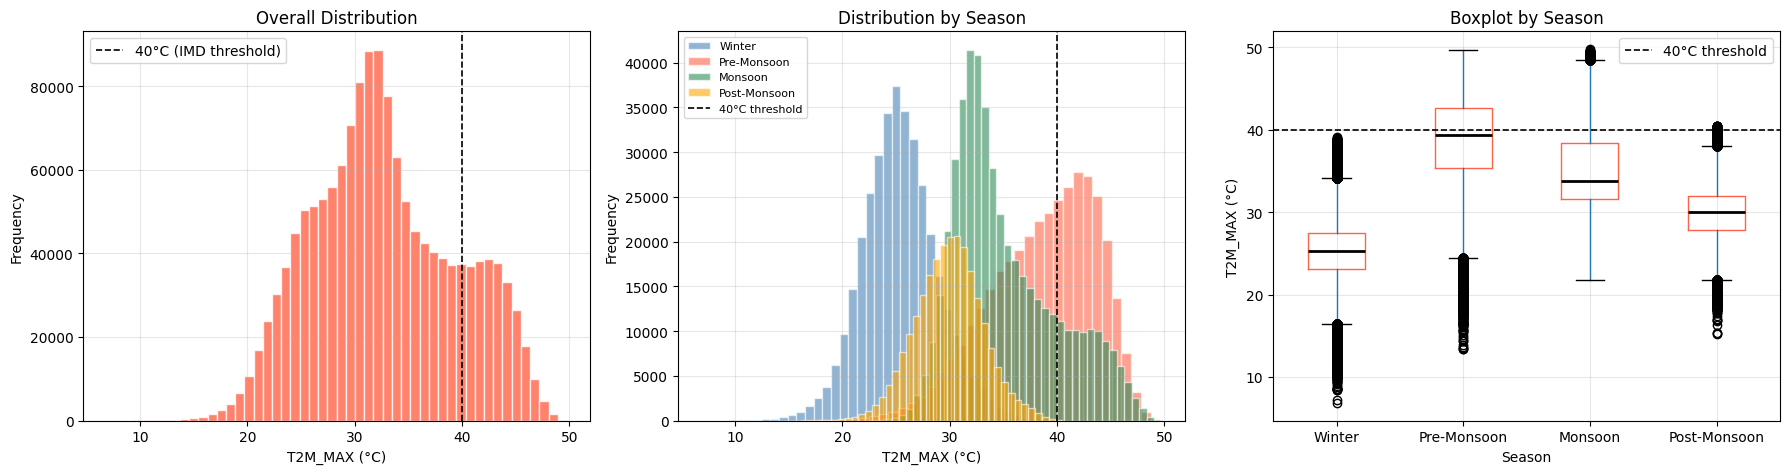

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('T2M_MAX Distribution — Training Data (1984–2015)', fontsize=14, fontweight='bold')

# Overall distribution
axes[0].hist(df_train['T2M_MAX'], bins=50, color='tomato', alpha=0.8, edgecolor='white')
axes[0].axvline(40, color='black', linestyle='--', linewidth=1.2, label='40°C (IMD threshold)')
axes[0].set_title('Overall Distribution')
axes[0].set_xlabel('T2M_MAX (°C)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution by season
df_train['month'] = df_train['date'].dt.month
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Pre-Monsoon', 4: 'Pre-Monsoon', 5: 'Pre-Monsoon',
              6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
              10: 'Post-Monsoon', 11: 'Post-Monsoon'}
df_train['season'] = df_train['month'].map(season_map)

season_colors = {'Winter': 'steelblue', 'Pre-Monsoon': 'tomato', 
                 'Monsoon': 'seagreen', 'Post-Monsoon': 'orange'}
for season, color in season_colors.items():
    subset = df_train[df_train['season'] == season]['T2M_MAX']
    axes[1].hist(subset, bins=40, alpha=0.6, label=season, color=color, edgecolor='white')
axes[1].axvline(40, color='black', linestyle='--', linewidth=1.2, label='40°C threshold')
axes[1].set_title('Distribution by Season')
axes[1].set_xlabel('T2M_MAX (°C)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Boxplot by season
season_order = ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']
df_train['season'] = pd.Categorical(df_train['season'], categories=season_order, ordered=True)
df_train.boxplot(column='T2M_MAX', by='season', ax=axes[2], 
                 boxprops=dict(color='tomato'),
                 medianprops=dict(color='black', linewidth=2))
axes[2].axhline(40, color='black', linestyle='--', linewidth=1.2, label='40°C threshold')
axes[2].set_title('Boxplot by Season')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('T2M_MAX (°C)')
axes[2].legend()
axes[2].grid(alpha=0.3)
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


* Pre-Monsoon is the danger zone — its distribution extends well past the 40°C threshold, which aligns perfectly with IMD's heatwave definition
* Monsoon peaks around 32–33°C — high but humid, heat stress is different
* Winter has the widest spread downward, some districts going below 10°CThe boxplot confirms Pre-Monsoon has the most outliers above 40°C


In [14]:
# Filter Pre-Monsoon only (March to June)
df['date'] = pd.to_datetime(df['date'])
pre_monsoon = df[df['date'].dt.month.isin([3, 4, 5, 6])]

results = []

for district, group in pre_monsoon.groupby('city'):
    yearly_max = group.groupby(group['date'].dt.year)['T2M_MAX'].mean()
    result = mk.original_test(yearly_max)
    results.append({
        'district': district,
        'trend': result.trend,
        'p_value': round(result.p, 4),
        'sens_slope': round(result.slope, 4)
    })

mk_results = pd.DataFrame(results).sort_values('sens_slope', ascending=False)
print(mk_results)

              district       trend  p_value  sens_slope
59              Kaimur    no trend   0.2785     -0.0159
115          Sonbhadra    no trend   0.2010     -0.0170
96              Rohtas    no trend   0.2418     -0.0186
122           Varanasi    no trend   0.1464     -0.0187
28           Chandauli    no trend   0.1861     -0.0193
..                 ...         ...      ...         ...
89         Parsa_Nepal  decreasing   0.0001     -0.0533
123     West_Champaran  decreasing   0.0001     -0.0541
64    Kapilvastu_Nepal  decreasing   0.0001     -0.0541
97     Rupandehi_Nepal  decreasing   0.0000     -0.0598
84   Nawalparasi_Nepal  decreasing   0.0000     -0.0668

[125 rows x 4 columns]


In [15]:
print(mk_results.to_string())

                district       trend  p_value  sens_slope
59                Kaimur    no trend   0.2785     -0.0159
115            Sonbhadra    no trend   0.2010     -0.0170
96                Rohtas    no trend   0.2418     -0.0186
122             Varanasi    no trend   0.1464     -0.0187
28             Chandauli    no trend   0.1861     -0.0193
23               Bhojpur    no trend   0.0791     -0.0199
42                Garhwa    no trend   0.1934     -0.0200
45              Ghazipur    no trend   0.1464     -0.0206
79              Mirzapur    no trend   0.1040     -0.0208
27                 Buxar    no trend   0.1186     -0.0216
11                Ballia  decreasing   0.0486     -0.0221
106              Sheopur    no trend   0.0720     -0.0229
20               Bhadohi    no trend   0.0791     -0.0244
102                Saran  decreasing   0.0461     -0.0244
13          Balrampur_CG    no trend   0.1721     -0.0250
49                  Guna  decreasing   0.0270     -0.0251
56            